In [137]:
import numpy as np 
import matplotlib.pyplot as plt 
import tensorflow as tf 
import gpflow as gpf
import scipy

In [138]:
import matplotlib.pyplot as plt
import numpy as np

import gpflow
from gpflow.ci_utils import reduce_in_tests

%matplotlib inline

plt.rcParams["figure.figsize"] = (12, 6)
np.random.seed(123)

(50, 1) (50, 1)


PearsonRResult(statistic=0.06743988827976169, pvalue=0.5049768040375985)

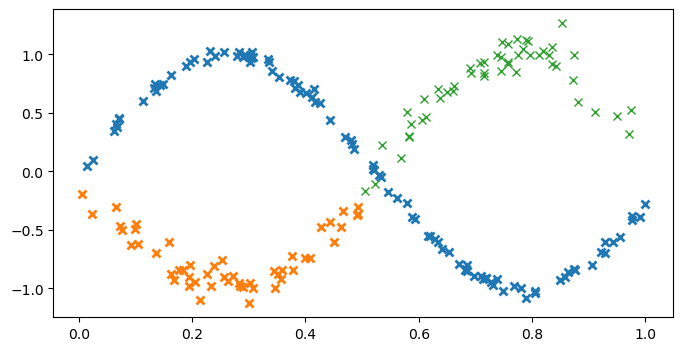

In [174]:
# make a dataset with two outputs, correlated, heavy-tail noise. One has more noise than the other.
X1 = np.random.rand(100, 1)  # Observed locations for first output
X2 = np.random.rand(50, 1) * 0.5  # Observed locations for second output
X_test = np.sort(0.5 + np.random.rand(50, 1)  * 0.5)
X_test = np.sort(X_test.flatten()).reshape(-1, 1)

Y1 = np.sin(6 * X1) + np.random.randn(*X1.shape) * 0.03
Y2 = np.sin(6 * X2 + 3.14) + np.random.randn(*X2.shape) * 0.1
Ytest = np.sin(6 * X_test + 3.14) + np.random.randn(*X_test.shape) * 0.1
print(Y2.shape, Ytest.shape)

plt.figure(figsize=(8, 4))
plt.plot(X1, Y1, "x", mew=2)
plt.plot(X2, Y2, "x", mew=2)
plt.plot(X_test, Ytest, "x")
scipy.stats.pearsonr(Y1.flatten(), np.concatenate((Y2, Ytest), axis=0).flatten())

In [175]:
# Augment the input with ones or zeros to indicate the required output dimension
X_augmented = np.vstack(
    (np.hstack((X1, np.zeros_like(X1))), np.hstack((X2, np.ones_like(X2))))
)

# Augment the Y data with ones or zeros that specify a likelihood from the list of likelihoods
Y_augmented = np.vstack(
    (np.hstack((Y1, np.zeros_like(Y1))), np.hstack((Y2, np.ones_like(Y2))))
)

In [176]:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpflow.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpflow.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg

In [177]:
# This likelihood switches between Gaussian noise with different variances for each f_i:
lik = gpflow.likelihoods.SwitchedLikelihood(
    [gpflow.likelihoods.Gaussian(), gpflow.likelihoods.Gaussian()]
)

ivs = np.random.choice(np.arange(len(X_augmented)), 20)
ivs = X_augmented[ivs]
ivs[:,1] = np.random.choice([0,1], len(ivs))
print(ivs)
# now build the GP model as normal
m = gpflow.models.SVGP(kernel=kern, likelihood=lik, inducing_variable=ivs, num_data=len(X_augmented))

# fit the covariance function parameters
maxiter = reduce_in_tests(10000)
gpflow.optimizers.Scipy().minimize(
    m.training_loss_closure((X_augmented, Y_augmented)),
    m.trainable_variables,
    options=dict(maxiter=maxiter),
    method="L-BFGS-B",
)

[[0.34679381 1.        ]
 [0.73820403 1.        ]
 [0.64127426 1.        ]
 [0.13700605 1.        ]
 [0.49261413 0.        ]
 [0.90492545 1.        ]
 [0.00516807 0.        ]
 [0.22617145 0.        ]
 [0.61948422 1.        ]
 [0.22656574 1.        ]
 [0.28940048 0.        ]
 [0.63428371 0.        ]
 [0.2336303  0.        ]
 [0.53267581 1.        ]
 [0.46293666 0.        ]
 [0.7132961  1.        ]
 [0.2336303  1.        ]
 [0.41171699 0.        ]
 [0.85717188 0.        ]
 [0.71786094 0.        ]]


2026-03-20 13:01:40.886388: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-03-20 13:01:40.922136: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -213.69973545310793
        x: [-2.003e-01  5.337e-01 ... -6.978e+00 -4.803e+00]
      nit: 8139
      jac: [-4.895e+00 -4.594e-01 ... -2.208e-02 -4.538e-04]
     nfev: 8902
     njev: 8902
 hess_inv: <278x278 LbfgsInvHessProduct with dtype=float64>

╒═════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════════╤═════════╤═══════════════════════════════════════════════════════╕
│ name                                    │ class     │ transform        │ prior   │ trainable   │ shape       │ dtype   │ value                                                 │
╞═════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════════╪═════════╪═══════════════════════════════════════════════════════╡
│ SVGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()          │ float64 │ 0.8251685618013571                                    │
├─────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────────┼─────────┼───────────────────────────────────────────────────────┤
│ SVGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()    

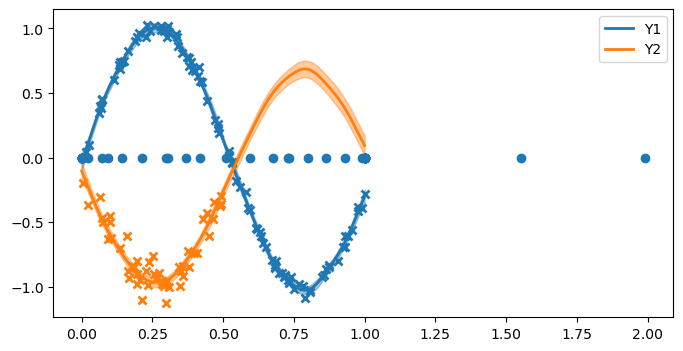

In [184]:
def plot_gp(x, mu, var, color, label):
    plt.plot(x, mu, color=color, lw=2, label=label)
    plt.fill_between(
        x[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color=color,
        alpha=0.4,
    )


def plot(m):
    plt.figure(figsize=(8, 4))
    Xtest = np.linspace(0, 1, 100)[:, None]
    (line,) = plt.plot(X1, Y1, "x", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.zeros_like(Xtest))))
    plot_gp(Xtest, mu, var, line.get_color(), "Y1")

    (line,) = plt.plot(X2, Y2, "x", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.ones_like(Xtest))))
    plot_gp(Xtest, mu, var, line.get_color(), "Y2")
    ivs = m.inducing_variable.Z.numpy() 
    plt.scatter(ivs, np.zeros_like(ivs))
    plt.legend()
    return np.mean((mu - Xtest) ** 2)


plot(m)

gpf.utilities.print_summary(m)
w = (m.kernel.kernels[1].W.numpy())
w = w @ w.T + np.diag(m.kernel.kernels[1].kappa)
print(w)

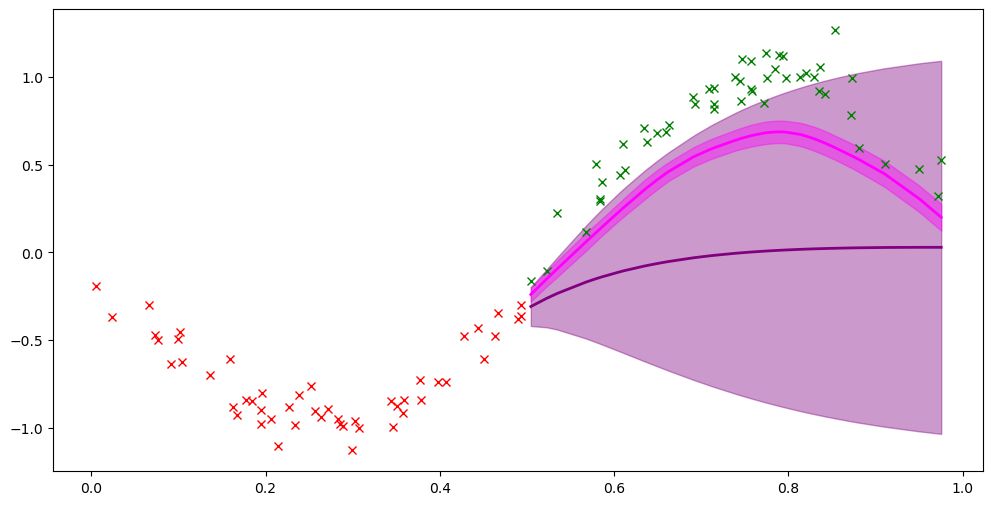

In [185]:
gpr = gpf.models.GPR((X2, Y2), kernel=gpf.kernels.Matern32())
opt = gpflow.optimizers.Scipy()
opt.minimize(gpr.training_loss, gpr.trainable_variables)
mu, var = gpr.predict_f(X_test)
plt.plot(X2, Y2, "rx")
plt.plot(X_test, Ytest, "gx")
plot_gp(X_test, mu, var, "purple", "single gp")
mu, var = m.predict_f(np.hstack((X_test, np.ones_like(X_test))))
plot_gp(X_test, mu, var, "magenta", "Y2")

### Balance test


******************** test 5000.0


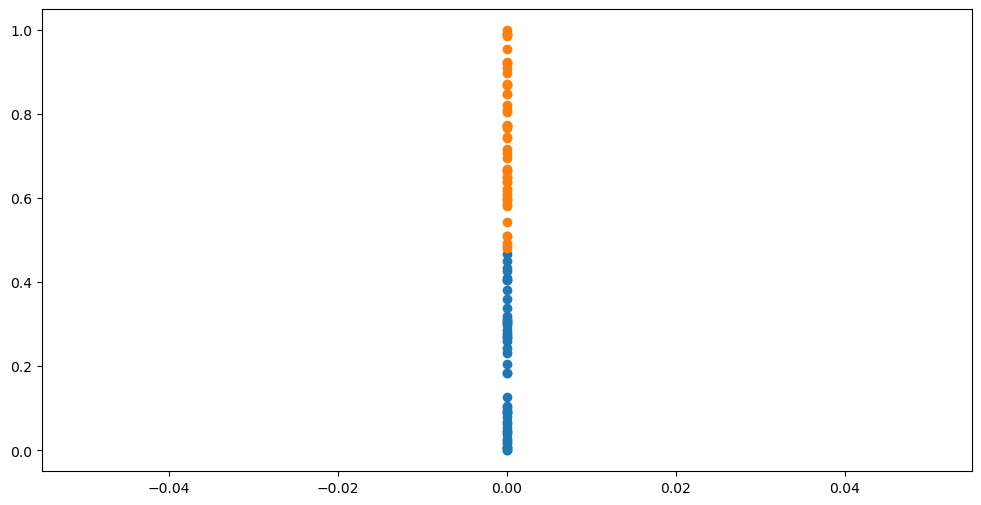

2026-03-20 13:04:10.450393: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-03-20 13:04:10.489740: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

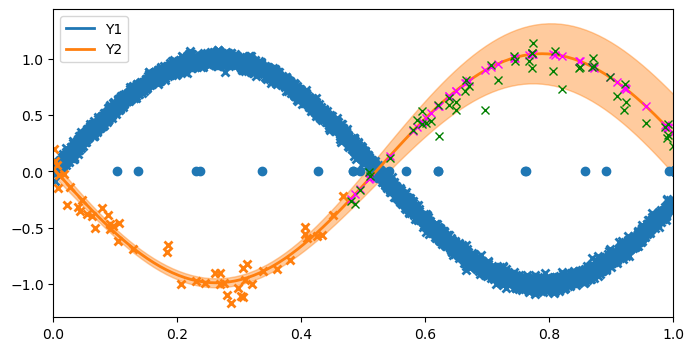

mse:  0.011519188395699407
******************** test 2320.79441680639


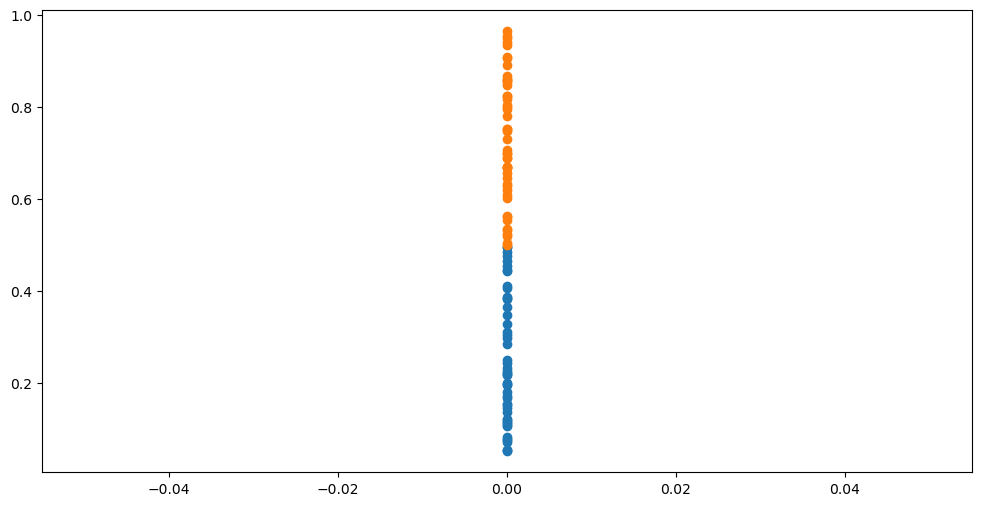

2026-03-20 13:05:07.886879: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-03-20 13:05:07.929357: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

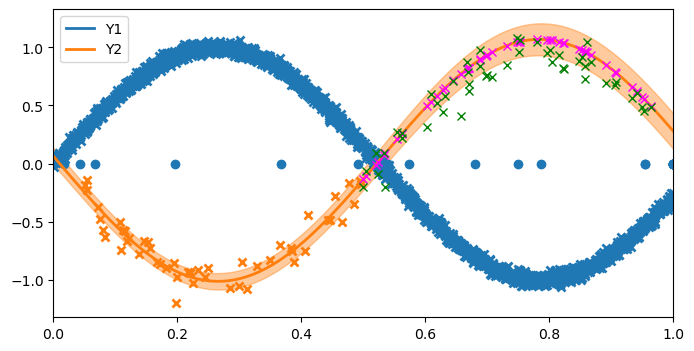

mse:  0.017642556290621045
******************** test 1077.217345015942


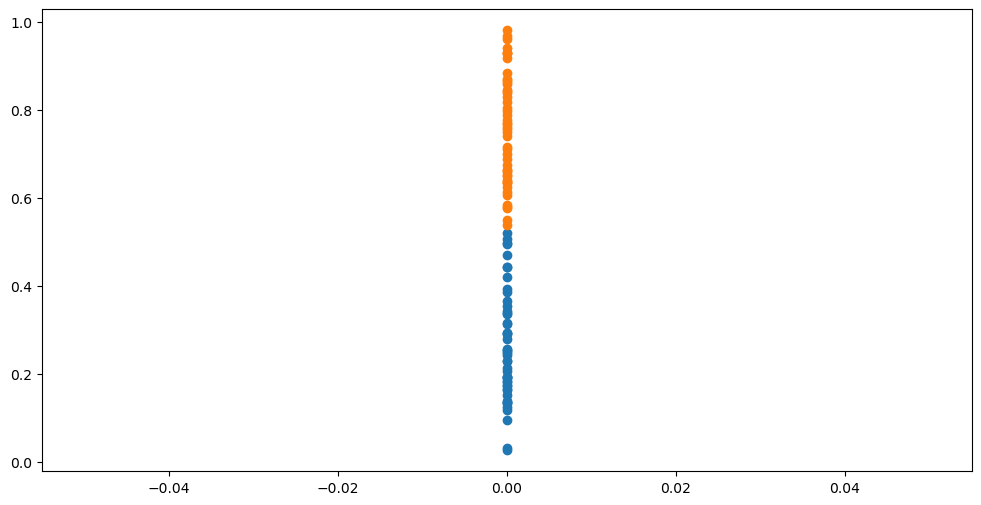

2026-03-20 13:05:38.282494: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-03-20 13:05:38.316204: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

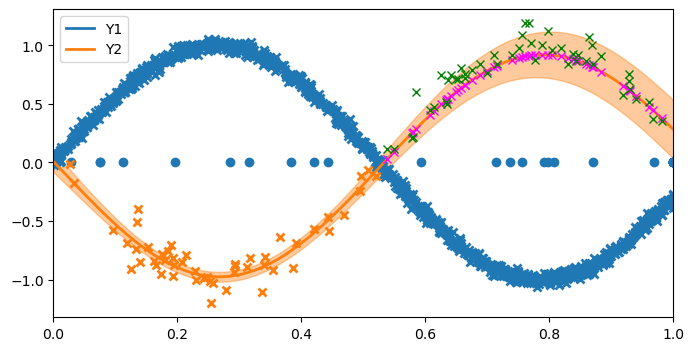

mse:  0.015263165730268084
******************** test 500.00000000000006


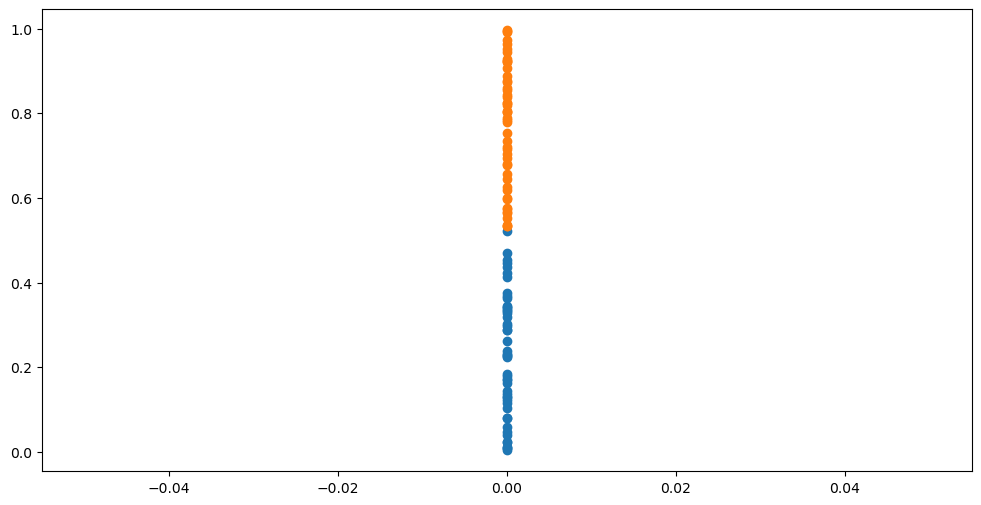

2026-03-20 13:05:52.003790: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-03-20 13:05:52.040499: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

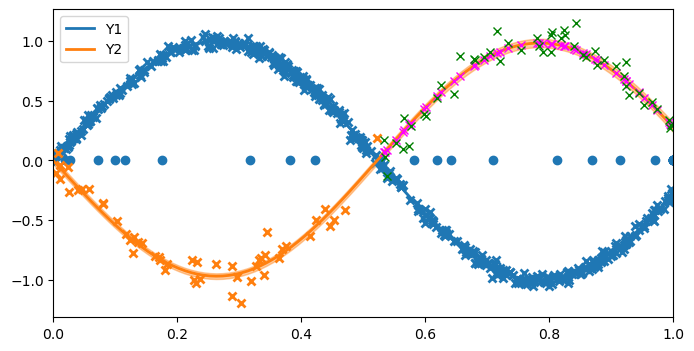

mse:  0.007909447550209569
******************** test 232.07944168063898


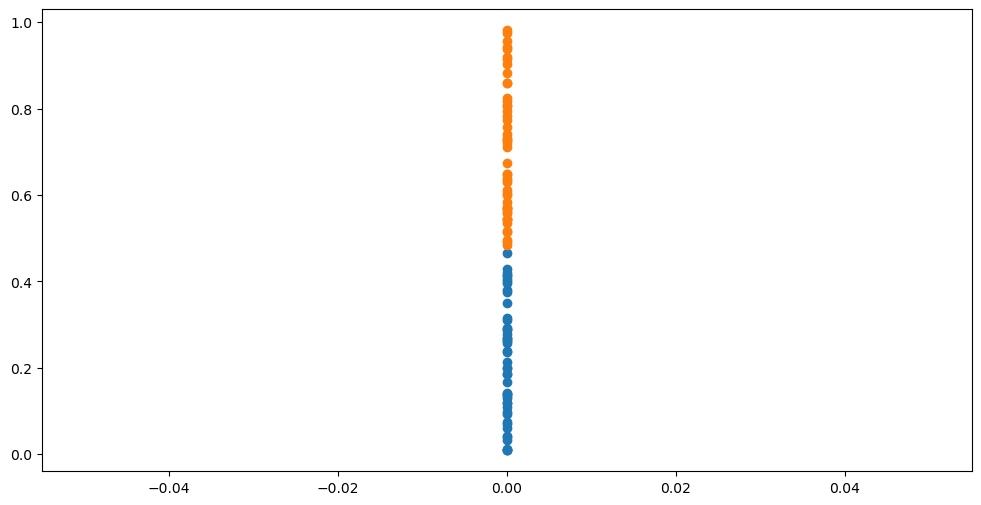

2026-03-20 13:06:03.985159: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-03-20 13:06:04.019810: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

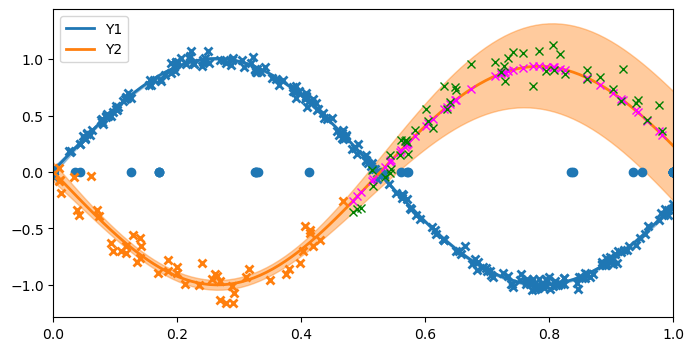

mse:  0.012115947132309185
******************** test 107.72173450159423


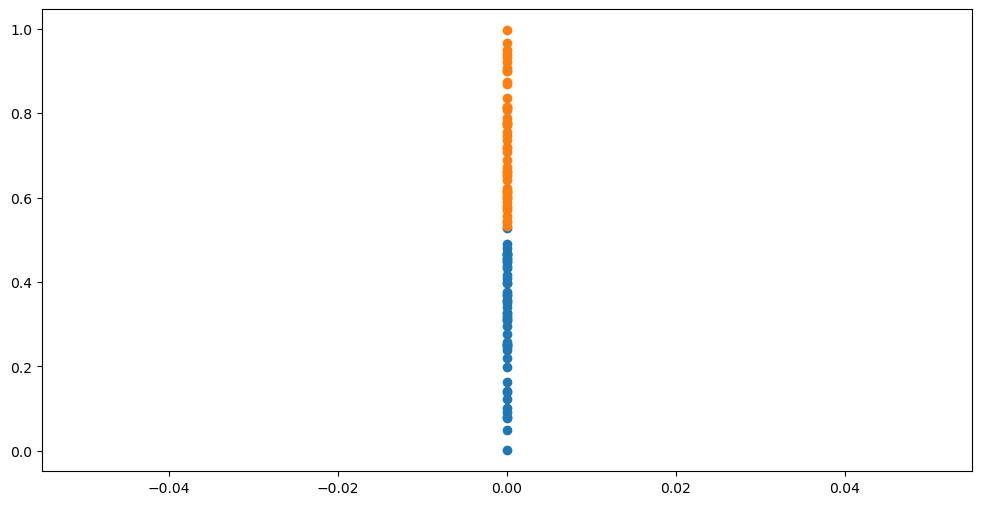

2026-03-20 13:06:13.880182: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-03-20 13:06:13.916573: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

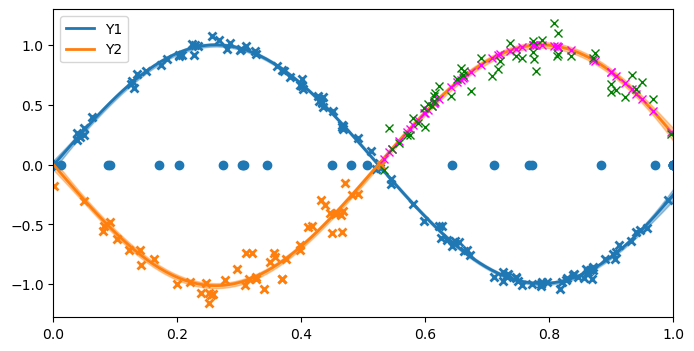

mse:  0.008999682407212854
******************** test 50.0


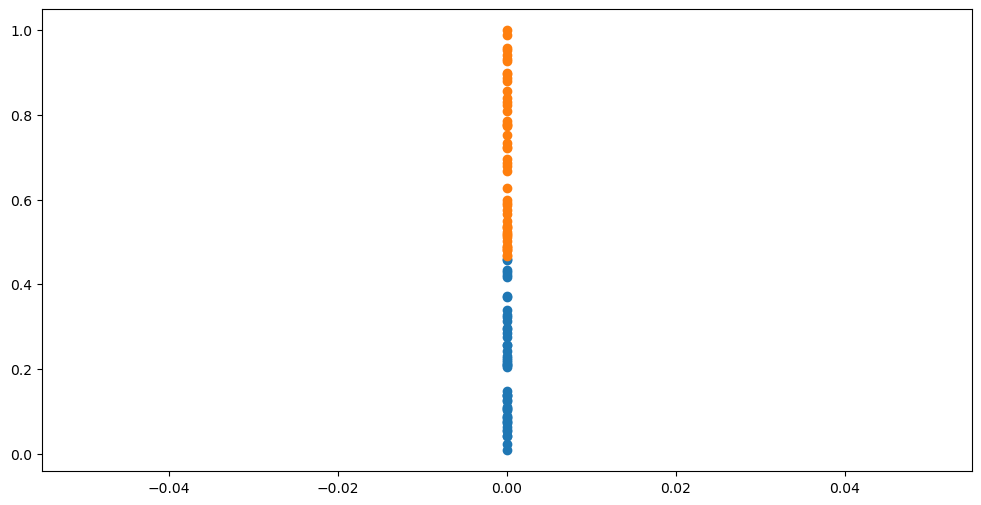

2026-03-20 13:06:21.208763: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-03-20 13:06:21.245504: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

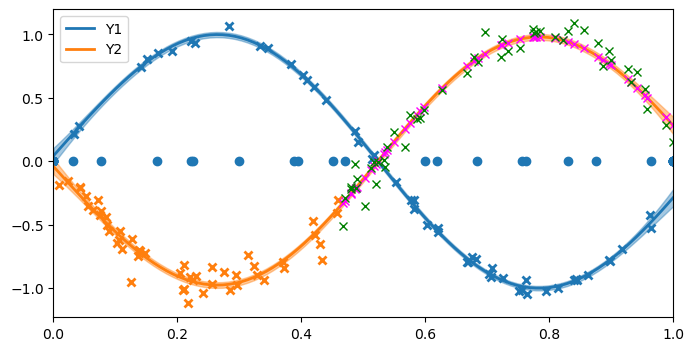

mse:  0.008055204907919895
******************** test 23.207944168063914


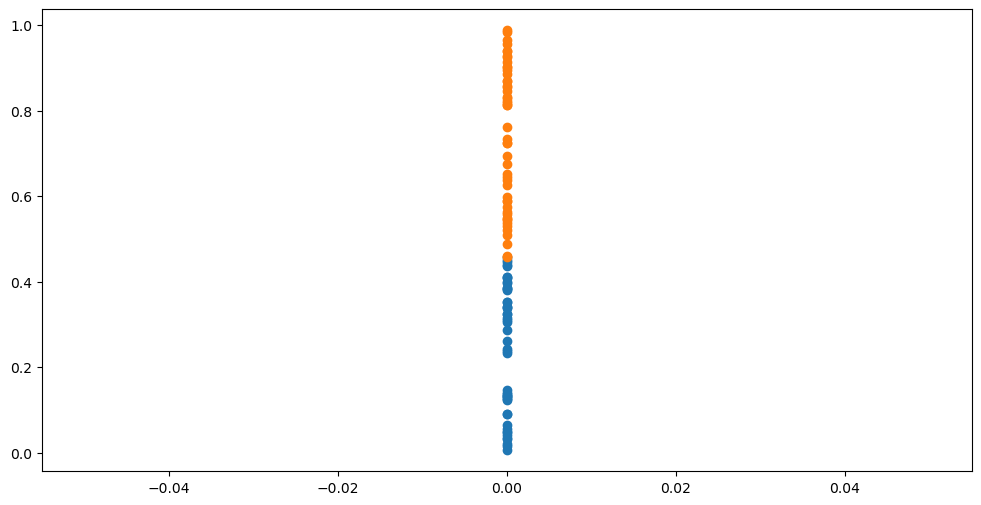

2026-03-20 13:06:27.977313: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-03-20 13:06:28.010534: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

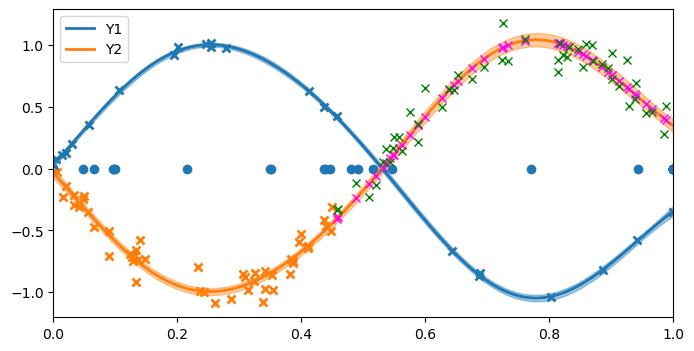

mse:  0.011208599140733444
******************** test 10.772173450159423


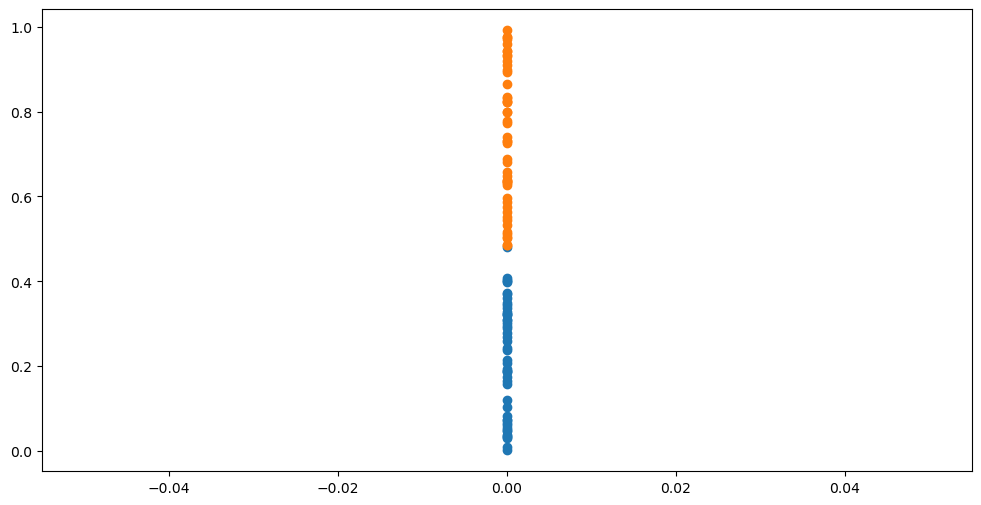

2026-03-20 13:06:38.008327: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-03-20 13:06:38.048186: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

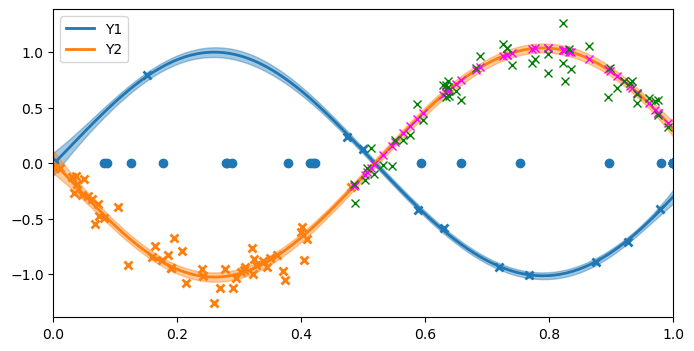

mse:  0.01256553231021336
******************** test 5.0


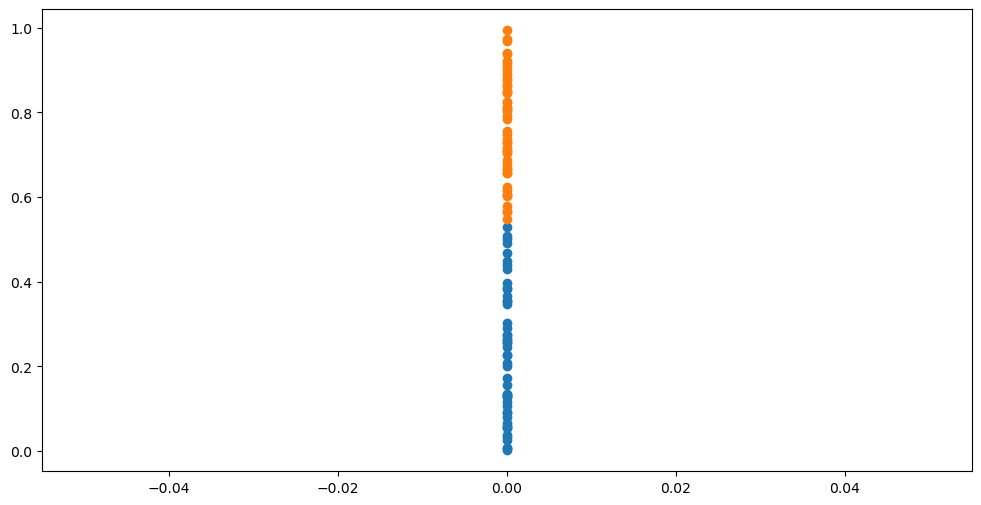

2026-03-20 13:06:47.244846: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-03-20 13:06:47.281302: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

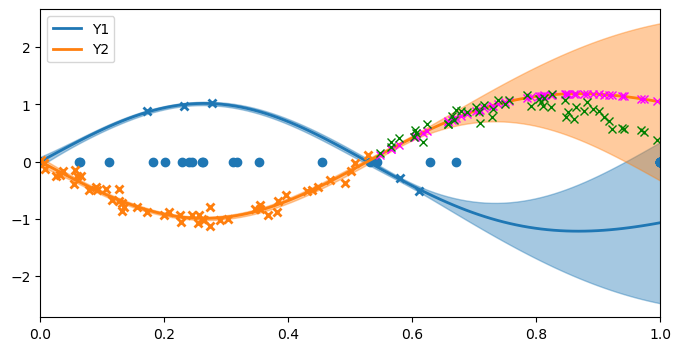

mse:  0.07096669346385581


In [187]:
# make a dataset with two outputs, correlated, heavy-tail noise. One has more noise than the other.
mses = []
for proportion in np.logspace(-2, 1, 10):
    print("*"*20, f"test {50*1/proportion}")
    X1 = np.random.rand(int(50*(1/proportion)), 1)  # Observed locations for first output
    Xall = np.sort(np.random.rand(100, 1), axis=0)# Observed locations for second output
    X2 = Xall[:50]
    X_test = Xall[50:]
    plt.scatter(np.zeros_like(X2), X2)
    plt.scatter(np.zeros_like(X_test), X_test)
    plt.show()

    Y1 = np.sin(6 * X1) + np.random.randn(*X1.shape) * 0.03
    Y2 = np.sin(6 * X2 + 3.14) + np.random.randn(*X2.shape) * 0.1
    Ytest = np.sin(6 * X_test + 3.14) + np.random.randn(*X_test.shape) * 0.1

    # Augment the input with ones or zeros to indicate the required output dimension
    X_augmented = np.vstack(
        (np.hstack((X1, np.zeros_like(X1))), np.hstack((X2, np.ones_like(X2))))
    )

    # Augment the Y data with ones or zeros that specify a likelihood from the list of likelihoods
    Y_augmented = np.vstack(
        (np.hstack((Y1, np.zeros_like(Y1))), np.hstack((Y2, np.ones_like(Y2))))
    )

    # Base kernel
    k = gpflow.kernels.RBF(active_dims=[0])

    # Coregion kernel
    coreg = gpflow.kernels.Coregion(
        output_dim=output_dim, rank=rank, active_dims=[1]
    )

    kern = k * coreg
    
    lik = gpflow.likelihoods.SwitchedLikelihood(
        [gpflow.likelihoods.Gaussian(), gpflow.likelihoods.Gaussian()]
    )

    ivs = np.random.choice(np.arange(len(X_augmented)), 20)
    ivs = X_augmented[ivs]
    ivs[:,1] = np.random.choice([0, 1], len(ivs))
    # now build the GP model as normal
    m = gpflow.models.SVGP(kernel=kern, likelihood=lik, inducing_variable=ivs, num_data=len(X_augmented))

    # fit the covariance function parameters
    maxiter = reduce_in_tests(9999)
    gpflow.optimizers.Scipy().minimize(
        m.training_loss_closure((X_augmented, Y_augmented)),
        m.trainable_variables,
        options=dict(maxiter=maxiter),
        method="L-BFGS-B",
    )

    mu1, var1 = m.predict_f(np.hstack((X_test, np.ones_like(X_test))))
    mse = np.mean((mu1 - Ytest) ** 2)
    plot(m)
    plt.plot(X_test, mu1, "x", color="magenta")
    plt.plot(X_test, Ytest, "x", color="green")

    plt.xlim([0, 1])
    plt.show()
    print("mse: ", mse)
    mses.append(mse)


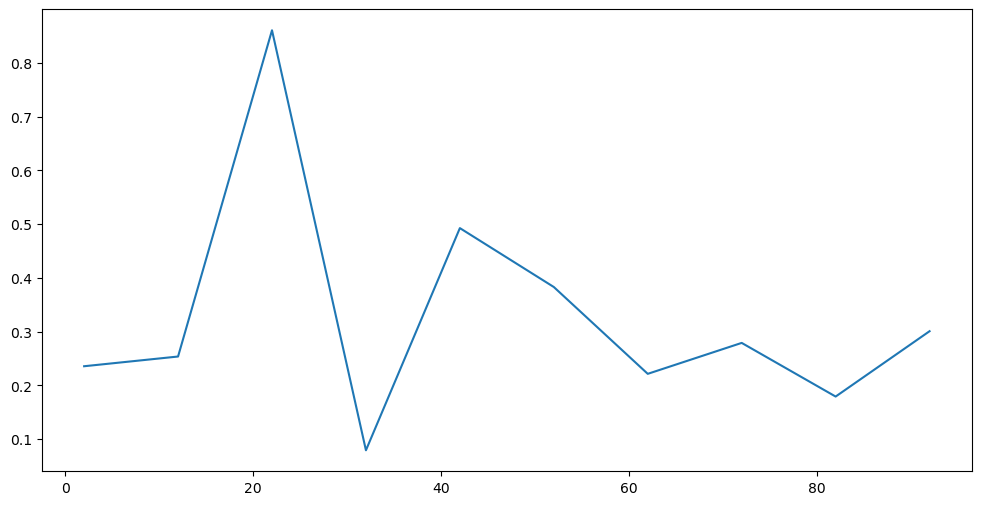

In [ ]:

plt.plot(np.arange(2, 100, 10), mses)
